In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_score, precision_recall_curve, recall_score, f1_score, average_precision_score

In [2]:
df = pd.read_csv(r'online_shoppers_intention_preprocessed.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12205 entries, 0 to 12204
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12205 non-null  int64  
 1   Administrative_Duration  12205 non-null  float64
 2   Informational            12205 non-null  int64  
 3   Informational_Duration   12205 non-null  float64
 4   ProductRelated           12205 non-null  int64  
 5   ProductRelated_Duration  12205 non-null  float64
 6   BounceRates              12205 non-null  float64
 7   ExitRates                12205 non-null  float64
 8   PageValues               12205 non-null  float64
 9   SpecialDay               12205 non-null  float64
 10  Month                    12205 non-null  int64  
 11  OperatingSystems         12205 non-null  int64  
 12  Browser                  12205 non-null  int64  
 13  Region                   12205 non-null  int64  
 14  TrafficType           

In [3]:
X = df.drop('Revenue', axis=1)
y = df['Revenue']

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32), 
    activation='relu', 
    solver='adam', 
    alpha=0.01, 
    learning_rate='adaptive', 
    max_iter=500,
    early_stopping=True,
    random_state=42
)

In [7]:
mlp.fit(X_train_scaled, y_train)
y_pred = mlp.predict(X_test_scaled)
y_probs = mlp.predict_proba(X_test_scaled)[:, 1]

In [8]:
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.8914379352724293

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.95      0.94      2079
           1       0.66      0.54      0.60       362

    accuracy                           0.89      2441
   macro avg       0.79      0.75      0.77      2441
weighted avg       0.88      0.89      0.89      2441



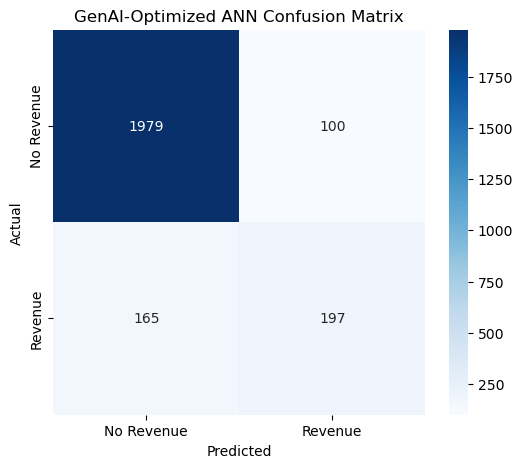

In [9]:
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Revenue', 'Revenue'], 
            yticklabels=['No Revenue', 'Revenue'])
plt.title('GenAI-Optimized ANN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
auc = roc_auc_score(y_test, y_probs)

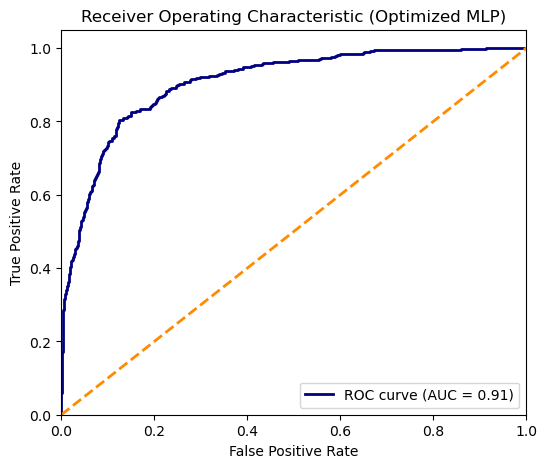

In [11]:
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='navy', lw=2, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], color='darkorange', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (Optimized MLP)')
plt.legend(loc="lower right")
plt.show()

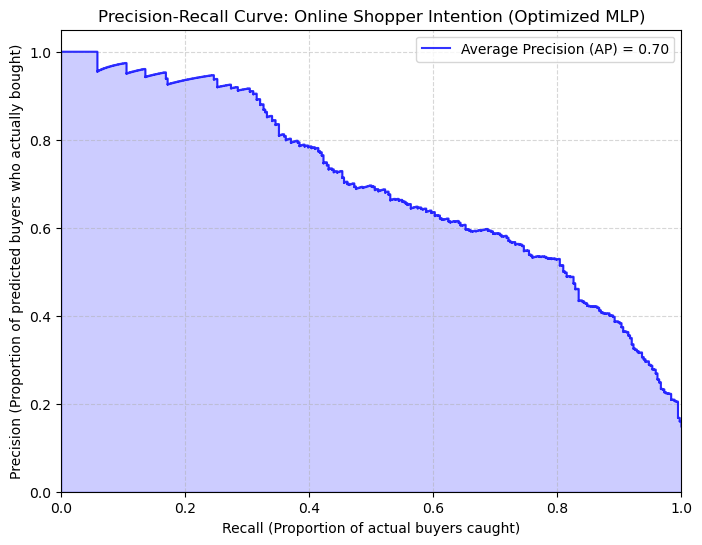

In [12]:
precision, recall, _ = precision_recall_curve(y_test, y_probs)
ap_score = average_precision_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.step(recall, precision, color='b', alpha=0.8, where='post', label=f'Average Precision (AP) = {ap_score:.2f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='b')

plt.xlabel('Recall (Proportion of actual buyers caught)')
plt.ylabel('Precision (Proportion of predicted buyers who actually bought)')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve: Online Shopper Intention (Optimized MLP)')
plt.legend(loc="upper right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [13]:
print(f"\nAverage Precision (AP): {ap_score:.4f}")


Average Precision (AP): 0.6970
